Langgraph Supervisor with RAG & Web crawler:
1. you have to create one supervisor node.
2. create one router function
3. create three more node
3.1 llm call (llm node)
3.2 RAG (rag node)
3.3 web crawler(fetch the info in realtime from internet)
4. created one more node after this for validation for generated output --> explore the validation part how to do that
5. if validation going to be failed in that case again go to supervioser node and then supervisor node will again decide what needs to be call next
6. once the validation will pass then only generate the final output



In [497]:
import os 
from dotenv import load_dotenv
load_dotenv()
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

### model 

In [498]:
from langchain_google_genai import ChatGoogleGenerativeAI
model =ChatGoogleGenerativeAI(model='gemini-1.5-flash')
model.invoke("Hi").content

'Hi there! How can I help you today?'

##### Tavily

In [499]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [500]:
tool =TavilySearchResults( tavily_api_key=TAVILY_API_KEY)
tool.invoke("mohanlal")

[{'title': 'Mohanlal - IMDb',
  'url': 'https://www.imdb.com/name/nm0482320/',
  'content': "and Santhakumari (mother) in the Pathanamthitta district of Kerala, which is located in the southern part of India on the 21st May 1960. Starting his career with a classic villain role, he has now become an outstanding actor in Malayalam Cinema. Without a doubt, Mohanlal is today's one of the best actors India has ever produced. He is also rated as one of the most talented actors in India. His ranges of movies are enviable, his comedy roles are incomparable and his unique style of dialogue",
  'score': 0.8029425},
 {'title': 'Mohanlal - Biography - IMDb',
  'url': 'https://www.imdb.com/name/nm0482320/bio/',
  'content': 'Mohanlal was born to Viswanathan Nair (father) and Santhakumari (mother) in the Pathanamthitta district of Kerala, which is located in the southern part of India on the 21st May 1960. Starting his career with a classic villain role, he has now become an outstanding actor in Mal

##### Embedding and Vector Store

In [501]:
from langchain_huggingface import  HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("hi"))

384

Load the doc 

In [502]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [503]:
loader = DirectoryLoader("../data2",loader_cls=TextLoader,glob="./*.txt")

In [504]:
doc = loader.load()

In [505]:
len(doc)

1

In [506]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size =200, chunk_overlap=50)

In [507]:
chunked_doc = text_splitter.split_documents(documents=doc)

In [508]:
chunked_doc

[Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='innovation, global trade, and finan

In [509]:
db = Chroma.from_documents(documents=chunked_doc,embedding=embeddings)

Retriver object for RAG

In [510]:
retriever = db.as_retriever(search_kwargs={'k': 3})

In [511]:
retriever.invoke("USA")

[Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy')]

#### Pydantic Parser and AgentState

In [512]:
from pydantic import BaseModel,Field
from langchain.output_parsers import PydanticOutputParser

import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

In [513]:
class TopicSelectionParser(BaseModel):
    Topic:str= Field(description="Selected Topic")
    Reasoning:str=Field(description="Reasoning behind selected topic")

parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)


class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage], operator.add]

In [514]:
from langchain.prompts import PromptTemplate

##### Supervisor Node

In [515]:
def function1(state:AgentState):
        question = state['messages'][-1]
        print("Question",question)

        template ="""
                Your task is to classify the given user query into one of the following categories:[USA,Web, Not Related].
               - Choose 'USA if query is related to the United States.
               - Choose 'Web' if the query requires real-time information from the internet (e.g., recent events, news, current things).
               - Choose 'Not Related' for all other queries.
               Only respond with the category name and reasoning in the specified format.
                User query :{question}
                {format_instructions}
                """
        prompt =PromptTemplate(
                template=template,
                input_variables=['question'],
                partial_variables={"format_instructions":parser.get_format_instructions}
        )
        chain= prompt | model | parser
        response = chain.invoke({'question':question})
        print("Parsed response:", response)
        return {"messages":[response.Topic]}
        

checking supervisor node output foe debugging

In [516]:
state = {"messages":["what is weather in melbourne today"]}
function1(state)

Question what is weather in melbourne today
Parsed response: Topic='Not Related' Reasoning="The query asks for the weather in Melbourne, which is not located in the USA.  It doesn't require real-time information beyond a current weather forecast, which is not considered 'real-time' in the same way as breaking news or stock prices."


{'messages': ['Not Related']}

#### Router 

In [517]:
def router(state:AgentState):
    print("-> Router ->")
    last_message = state["messages"][-1]

    if "web" in last_message.lower():
        return "WEB Call"
    elif "usa" in last_message.lower():
        return "RAG Call"
    else:
        return "LLM Call"

##### LLM Node

In [518]:
def function2(state:AgentState):
    print("-> LLM Call ->")
    
    question = state["messages"][0]
    query = "Answer the follow question with you knowledge of the real world. Following is the user question:"+question
    response= model.invoke(query)
    return {'messages':[response.content]}

In [519]:
state = {"messages":["what is Independant?"]}
function2(state)

-> LLM Call ->


{'messages': ['"Independent" means free from outside control or influence.  It can apply to many things:\n\n* **A person:** An independent person is self-reliant, makes their own decisions, and doesn\'t rely heavily on others for support or guidance.  They think for themselves.\n\n* **A country:** An independent country is a sovereign state, not controlled by another nation.\n\n* **A business:** An independent business is not part of a larger corporation or franchise.  It\'s owned and operated separately.\n\n* **A variable (in statistics or programming):** An independent variable is one that\'s manipulated or changed to observe its effect on another variable (the dependent variable).\n\n* **A clause (in grammar):** An independent clause is a complete sentence that can stand alone.\n\nIn short, the meaning of "independent" hinges on freedom from external control or dependence on something else.']}

#### RAG Node

In [520]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [521]:
def function3(state:AgentState):
    print("-> RAG ->")
    question = state['messages'][0]
    prompt = PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:""",
        
        input_variables=['context', 'question']
    )
    
    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
    )
    result = rag_chain.invoke(question)
    
    return {"messages":[result]}

In [522]:
state = {"messages":[" usa economy ?"]}
function3(state)

-> RAG ->


{'messages': ['I need more information to answer your question about the US economy.  The provided context only repeats "Overview of the U.S. Economy" and gives no details.']}

#### Web Crawler 

In [523]:
from langchain_community.tools.tavily_search import TavilySearchResults
tool =TavilySearchResults( tavily_api_key=TAVILY_API_KEY)

In [524]:
search_result = tool.run("usa ")
#context = "\n".join(doc['content'] for doc in search_result)
search_result[0]['content']

'The United States of America (USA), also known as the United States (U.S.) or America, is a country primarily located in North America. It is a federal republic of 50 states and a federal capital district, Washington, D.C. The 48 contiguous states border Canada to the north and Mexico to the south, with the semi-exclave of Alaska in the northwest and the archipelago of Hawaii in the Pacific Ocean. The United States also asserts sovereignty over five major island territories and various [...] The term "United States" and its initialism "U.S.", used as nouns or as adjectives in English, are common short names for the country. The initialism "USA", a noun, is also common.( "United States" and "U.S." are the established terms throughout the U.S. federal government, with prescribed rules.( "The States" is an established colloquial shortening of the name, used particularly from abroad;( "stateside" is the corresponding adjective or adverb.( [...] The U.S. national government is a presidenti

In [525]:
def function4(state:AgentState):
    print("-.Web Crawler ->")
    question = state['messages'][0]
    search_result = tool.run(question)
    context = "\n".join(doc['content'] for doc in search_result)


    prompt = PromptTemplate(
            template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context from a web search to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
            Question: {question}
            Context: {context}
            Answer:""",
            input_variables=['context', 'question']
        )
    web_chain = (
        {"context":RunnableLambda(lambda x:context),"question":RunnablePassthrough()}
        |prompt
        |model
        |StrOutputParser()
    )
    response = web_chain.invoke(question)
    return {"messages":[response]}

In [526]:
state = {"messages":["Whats happening in melbourne today?"]}
function4(state)

-.Web Crawler ->


{'messages': ["Based on the provided text, there is a 20-year reunion for Melbourne High School classes of 2004 & 2005 tomorrow at 6:00 PM,  a scavenger hunt for couples at 1:00 PM, and a Corey Congilio live performance at Heidi's Jazz Club at 7:00 PM.  Other events and activities are listed but lack specific times."]}

#### Validation node

In [527]:
def function5(state:AgentState):
    print("-> Validation Node -> ")

    question = state["messages"][0]
    answer =state["messages"][-1]
    template ="""
                Your task is to validate the answer based on question and classify into one of the following categories:[Accept,Revoke].
               - Choose Accept,  if An answer is valid if it directly addresses the question, and is at least one sentence long.
               - Choose Revoke, if it doesnot .
               Only respond with the category name and reasoning in the specified format.
                question :{question}
                answer : {answer}
                {format_instructions}
                """
    prompt = PromptTemplate(
        template=template,
        input_variables=['question','answer'],
        partial_variables={'format_instructions':parser.get_format_instructions()}
    )
    chain = prompt |model |parser

    response= chain.invoke({"question":question,"answer":answer})
    print("Validation result:", response)

    return {"messages":[response.Topic]}

In [528]:
function5({'messages':['what happend after the  rcb winning ceremony','During the Royal Challengers Bengalurus (RCB) victory ceremony after their IPL triumph, a stampede occurred outside the M Chinnaswamy Stadium due to the large crowd. Tragically, at least 11 people died and over 30 were injured. The event inside the stadium was cut short, and a planned bus parade was canceled.\n']})

-> Validation Node -> 
Validation result: Topic='Accept' Reasoning="The answer directly addresses the question by describing the events that happened after RCB's winning ceremony, including the stampede, casualties, and cancellation of planned events.  It is more than one sentence long."


{'messages': ['Accept']}

In [529]:
state = {"messages":["Whats happening in melbourne today?" ,"Several events are happening in Melbourne today, including High Cheese, Open House Melbourne, Winter Glow, Beetlejuice the Musical, Mother Play, and Lightscape.  There\'s also a murder mystery event at 10:30 PM and an R&B vs Trap Therapy event at 8:00 PM.  More information can be found by searching online for things to do in Melbourne today "]}
function5(state)

-> Validation Node -> 
Validation result: Topic='Accept' Reasoning='The answer lists several events happening in Melbourne today, directly addressing the question and providing multiple examples. It also suggests a way to find more information.'


{'messages': ['Accept']}

### Validation Router

In [530]:
def validation_router(state:AgentState):
    print("-> Validation Router ->")
    last_message = state["messages"][-1]
    print(last_message)
    if "accept" in last_message.lower():
        return "Accept :Result Call"
    else :
        return "Revoke :Supervisor Call"
        
    

#### SHOW Result and End Node

In [531]:
def function6(state:AgentState):
    print("-> Result Node->")
    question = state["messages"][0]
    answer =state["messages"][2]
    print("final_result: ",answer)
    return {'messages':[answer]}


#### Initialise Workflow

In [532]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

Add nodes

In [533]:
workflow.add_node("Supervisor",function1)
workflow.add_node("LLM",function2)
workflow.add_node("RAG",function3)
workflow.add_node("WEB",function4)
workflow.add_node("VALIDATION",function5)
workflow.add_node("Result",function6)

Entry point

In [534]:
workflow.set_entry_point("Supervisor")

conditional edges

In [535]:
workflow.add_conditional_edges("Supervisor",
                               router,
                               {"LLM Call":"LLM",
                                "RAG Call":"RAG",
                                "WEB Call":"WEB"}
                              )

Adding edges

In [536]:
workflow.add_edge("LLM","VALIDATION")
workflow.add_edge("RAG","VALIDATION")
workflow.add_edge("WEB","VALIDATION")

Condtional edges

In [537]:
workflow.add_conditional_edges(
    "VALIDATION",
    validation_router,
    {
        "Accept :Result Call":"Result"
        ,"Revoke :Supervisor Call":"Supervisor"
    }
)

add edge

In [538]:
workflow.add_edge("Result",END)

Exit point

In [539]:
#workflow.set_finish_point("Result")

Compiling the graph

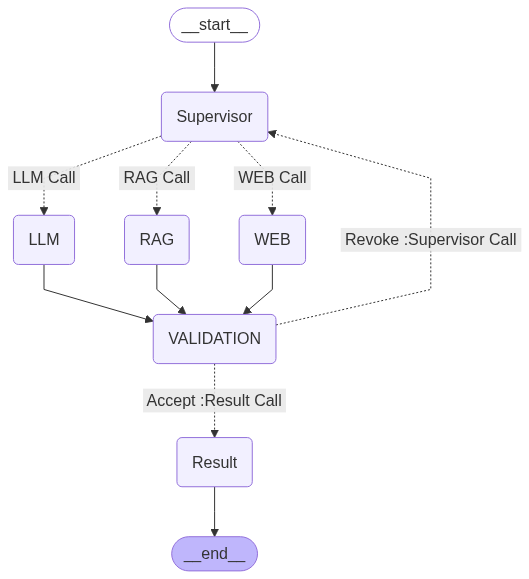

In [540]:
workflow.compile()

In [541]:
app = workflow.compile()

#### TEst case

In [542]:
state = {"messages": ["what happend after the  rcb winning ceremony"]}
result = app.invoke(state)

Question what happend after the  rcb winning ceremony
Parsed response: Topic='Web' Reasoning='The query asks about events that happened after a ceremony, which requires accessing information from the internet, likely news articles or social media posts about the event.'
-> Router ->
-.Web Crawler ->
-> Validation Node -> 
Validation result: Topic='Accept' Reasoning="The answer directly addresses the question by describing the events that followed RCB's winning ceremony.  It provides details about the stampede, its consequences, and subsequent actions taken. The answer is more than one sentence long."
-> Validation Router ->
Accept
-> Result Node->
final_result:  Following RCB's victory ceremony, a stampede occurred outside the M. Chinnaswamy Stadium in Bengaluru, resulting in 11 deaths and numerous injuries due to severe overcrowding.  The incident led to investigations, compensation for victims' families, and the suspension of several police officials.
